# Notebook 07 (Revised) — Final Benchmarking and Evaluation

This notebook loads the per-fold metrics saved by notebooks 05 and 06
and performs the final benchmarking comparison of PLS-DA, SVM, and 1D-CNN.
No models are retrained here — only saved results are loaded and analyzed.

## Section 1 — Imports and Setup

We import all required libraries and configure plot styles. Output directories for
figures and results are created if they do not already exist. No model libraries
such as TensorFlow or Keras are imported — this notebook only loads and analyzes
previously saved JSON results.

In [15]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2
from sklearn.metrics import confusion_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11

os.makedirs('../../docs/figures', exist_ok=True)
os.makedirs('../../data/results', exist_ok=True)

print("Setup complete.")

Setup complete.


## Section 2 — Load Saved Results

Per-fold metrics and combined predictions from all 5 folds are loaded
from JSON files saved by notebooks 05 and 06. Each JSON file contains
per-fold metrics, mean and std of each metric, and the combined
predictions across all 5 folds covering all 80 original samples.

In [16]:
with open('../../data/results/plsda_results.json') as f:
    plsda = json.load(f)

with open('../../data/results/svm_results.json') as f:
    svm = json.load(f)

with open('../../data/results/cnn_results.json') as f:
    cnn = json.load(f)

print("Results loaded successfully.")
print(f"PLS-DA : {len(plsda['fold_metrics'])} folds")
print(f"SVM    : {len(svm['fold_metrics'])} folds")
print(f"1D-CNN : {len(cnn['fold_metrics'])} folds")

# Helper to safely get f1 value from fold metric dict
def get_f1(m):
    return m.get('f1_score', m.get('f1', 0.0))

Results loaded successfully.
PLS-DA : 5 folds
SVM    : 5 folds
1D-CNN : 5 folds


## Section 3 — Summary of Mean Metrics Across 5 Folds

This table summarizes the mean and standard deviation of Accuracy,
Precision, Recall, and F1-Score across all 5 folds for each model.
Standard deviation indicates how consistent each model is across folds.

In [17]:
rows = []
for label, res in [('PLS-DA', plsda), ('SVM', svm), ('1D-CNN', cnn)]:
    rows.append({
        'Model':     label,
        'Accuracy':  f"{res['mean_accuracy']:.4f} +/- {res['std_accuracy']:.4f}",
        'Precision': f"{res['mean_precision']:.4f} +/- {res['std_precision']:.4f}",
        'Recall':    f"{res['mean_recall']:.4f} +/- {res['std_recall']:.4f}",
        'F1-Score':  f"{res['mean_f1']:.4f} +/- {res['std_f1']:.4f}",
    })

summary_df = pd.DataFrame(rows)
display(summary_df)

best_by_f1 = max(
    [('PLS-DA', plsda), ('SVM', svm), ('1D-CNN', cnn)],
    key=lambda x: x[1]['mean_f1']
)[0]
print(f"\nHighest mean F1-Score: {best_by_f1}")

,Model,Accuracy,Precision,Recall,F1-Score
0,PLS-DA,0.7375 +/- 0.1275,0.7389 +/- 0.1115,0.7500 +/- 0.2739,0.7145 +/- 0.1919
1,SVM,0.7750 +/- 0.0848,0.8187 +/- 0.1215,0.7250 +/- 0.0935,0.7640 +/- 0.0840
2,1D-CNN,0.8125 +/- 0.0395,0.8075 +/- 0.0492,0.8250 +/- 0.0612,0.8144 +/- 0.0405



Highest mean F1-Score: 1D-CNN


## Section 4 — Per-Fold Metrics

This table shows the individual metrics for each fold across all three
models. Consistent values across folds indicate a robust model that
generalizes well regardless of which 16 samples are held out as the test set.

In [18]:
fold_rows = []
for label, res in [('PLS-DA', plsda), ('SVM', svm), ('1D-CNN', cnn)]:
    for i, m in enumerate(res['fold_metrics']):
        fold_rows.append({
            'Model':     label,
            'Fold':      i + 1,
            'Accuracy':  round(m['accuracy'],  4),
            'Precision': round(m['precision'], 4),
            'Recall':    round(m['recall'],    4),
            'F1-Score':  round(get_f1(m),      4),
        })

fold_df = pd.DataFrame(fold_rows)
display(fold_df)

,Model,Fold,Accuracy,Precision,Recall,F1-Score
0,PLS-DA,1,0.9375,0.8889,1.000,0.9412
1,PLS-DA,2,0.6875,0.6667,0.750,0.7059
2,PLS-DA,3,0.5625,0.6667,0.250,0.3636
3,PLS-DA,4,0.6875,0.6154,1.000,0.7619
4,PLS-DA,5,0.8125,0.8571,0.750,0.8000
5,SVM,1,0.8125,0.7778,0.875,0.8235
6,SVM,2,0.6250,0.6250,0.625,0.6250
7,SVM,3,0.8125,0.8571,0.750,0.8000
8,SVM,4,0.7500,0.8333,0.625,0.7143
9,SVM,5,0.8750,1.0000,0.750,0.8571


## Section 5 — Model Performance Comparison

This grouped bar chart compares the mean performance of all three models
across four evaluation metrics. Error bars represent the standard deviation
across 5 folds — smaller error bars indicate more consistent performance.

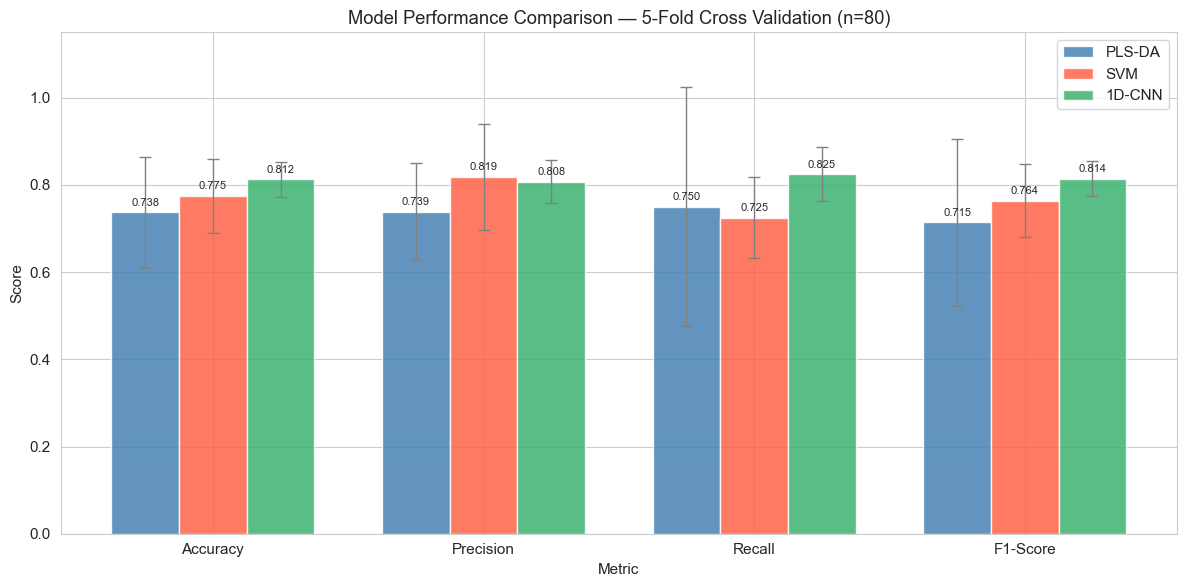

Saved: docs/figures/comparison_bar_chart.png


In [19]:
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_keys = [('mean_accuracy', 'std_accuracy'),
               ('mean_precision', 'std_precision'),
               ('mean_recall', 'std_recall'),
               ('mean_f1', 'std_f1')]

models_data = {
    'PLS-DA': {
        'means':  [plsda[mk] for mk, _ in metric_keys],
        'stds':   [plsda[sk] for _, sk in metric_keys],
        'color':  'steelblue',
    },
    'SVM': {
        'means':  [svm[mk] for mk, _ in metric_keys],
        'stds':   [svm[sk] for _, sk in metric_keys],
        'color':  'tomato',
    },
    '1D-CNN': {
        'means':  [cnn[mk] for mk, _ in metric_keys],
        'stds':   [cnn[sk] for _, sk in metric_keys],
        'color':  'mediumseagreen',
    },
}

x         = np.arange(len(metrics))
bar_width = 0.25
offsets   = [-bar_width, 0, bar_width]

fig, ax = plt.subplots(figsize=(12, 6))

for (name, data), offset in zip(models_data.items(), offsets):
    bars = ax.bar(
        x + offset, data['means'], bar_width,
        yerr=data['stds'], capsize=4,
        color=data['color'], alpha=0.85,
        error_kw={'ecolor': 'gray', 'elinewidth': 1},
        label=name,
    )
    for bar, mean_val in zip(bars, data['means']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{mean_val:.3f}',
            ha='center', va='bottom', fontsize=8,
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — 5-Fold Cross Validation (n=80)')
ax.legend()
plt.tight_layout()
plt.savefig('../../docs/figures/comparison_bar_chart.png', bbox_inches='tight')
plt.show()
print("Saved: docs/figures/comparison_bar_chart.png")

## Section 6 — Combined Confusion Matrices

Each confusion matrix aggregates predictions from all 5 folds meaning
each of the 80 original samples appears exactly once as a test sample.
This gives a complete picture of each model's classification behavior
across the entire dataset.

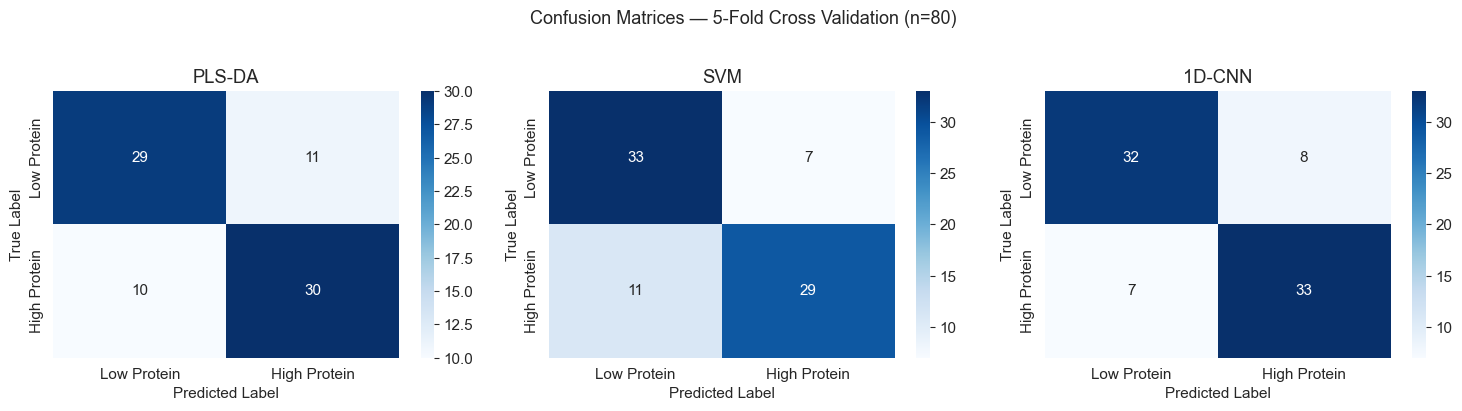

Saved: docs/figures/confusion_matrices.png


In [20]:
y_true_plsda = np.array(plsda['all_y_true'])
y_pred_plsda = np.array(plsda['all_y_pred'])
y_true_svm   = np.array(svm['all_y_true'])
y_pred_svm   = np.array(svm['all_y_pred'])
y_true_cnn   = np.array(cnn['all_y_true'])
y_pred_cnn   = np.array(cnn['all_y_pred'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_data = [
    ('PLS-DA', y_true_plsda, y_pred_plsda),
    ('SVM',    y_true_svm,   y_pred_svm),
    ('1D-CNN', y_true_cnn,   y_pred_cnn),
]

for ax, (name, y_true, y_pred) in zip(axes, plot_data):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Low Protein', 'High Protein'],
        yticklabels=['Low Protein', 'High Protein'],
    )
    ax.set_title(name)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

fig.suptitle('Confusion Matrices — 5-Fold Cross Validation (n=80)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../../docs/figures/confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Saved: docs/figures/confusion_matrices.png")

## Section 7 — McNemar's Test for Statistical Significance

McNemar's test determines whether the difference in performance between
two classifiers is statistically significant or could be due to random chance.
It examines cases where one model was correct and the other was wrong.
A p-value below 0.05 indicates a statistically significant difference.

Three pairwise comparisons are performed:
- PLS-DA vs SVM
- PLS-DA vs 1D-CNN
- SVM vs 1D-CNN

In [21]:
def mcnemar_test(y_true, y_pred_a, y_pred_b):
    """
    Performs McNemar's test comparing two classifiers.
    Uses continuity correction for small sample sizes.
    Returns chi-square statistic and p-value.
    """
    y_true   = np.array(y_true)
    y_pred_a = np.array(y_pred_a)
    y_pred_b = np.array(y_pred_b)

    b = np.sum((y_pred_a == y_true) & (y_pred_b != y_true))
    c = np.sum((y_pred_a != y_true) & (y_pred_b == y_true))

    if (b + c) == 0:
        return 0.0, 1.0

    statistic = (abs(b - c) - 1) ** 2 / (b + c)
    p_value   = 1 - chi2.cdf(statistic, df=1)
    return float(statistic), float(p_value)


pairs = [
    ('PLS-DA', 'SVM',    y_true_plsda, y_pred_plsda, y_pred_svm),
    ('PLS-DA', '1D-CNN', y_true_plsda, y_pred_plsda, y_pred_cnn),
    ('SVM',    '1D-CNN', y_true_svm,   y_pred_svm,   y_pred_cnn),
]

mcnemar_results = []
for name_a, name_b, y_true, y_pred_a, y_pred_b in pairs:
    stat, p     = mcnemar_test(y_true, y_pred_a, y_pred_b)
    significant = 'Yes' if p < 0.05 else 'No'
    mcnemar_results.append({
        'Comparison':           f'{name_a} vs {name_b}',
        'Statistic':            round(stat, 4),
        'p-value':              round(p, 4),
        'Significant (p<0.05)': significant,
    })
    print(f"{name_a} vs {name_b}: statistic={stat:.4f}  p={p:.4f}  significant={significant}")

mcnemar_df = pd.DataFrame(mcnemar_results)
display(mcnemar_df)

PLS-DA vs SVM: statistic=0.1739  p=0.6767  significant=No
PLS-DA vs 1D-CNN: statistic=1.3889  p=0.2386  significant=No
SVM vs 1D-CNN: statistic=0.2667  p=0.6056  significant=No


,Comparison,Statistic,p-value,Significant (p<0.05)
0,PLS-DA vs SVM,0.1739,0.6767,No
1,PLS-DA vs 1D-CNN,1.3889,0.2386,No
2,SVM vs 1D-CNN,0.2667,0.6056,No


## Section 8 — Best Model Selection

The best model is selected based on the highest mean F1-Score across
5 folds. F1-Score is chosen as the primary metric because it balances
precision and recall — both false positives and false negatives have
practical consequences in protein classification for grain quality assessment.

In [22]:
models_summary = {
    'PLS-DA': plsda,
    'SVM':    svm,
    '1D-CNN': cnn,
}

best_model_name = max(models_summary, key=lambda k: models_summary[k]['mean_f1'])
best_model      = models_summary[best_model_name]

print("=" * 56)
print("  Best Model Selection")
print("=" * 56)
for name, res in models_summary.items():
    marker = " <-- BEST" if name == best_model_name else ""
    print(f"  {name:10s} | F1: {res['mean_f1']:.4f} +/- {res['std_f1']:.4f}{marker}")
print("=" * 56)
print(f"\nSelected best model : {best_model_name}")
print(f"Mean F1-Score       : {best_model['mean_f1']:.4f} +/- {best_model['std_f1']:.4f}")
print(f"Mean Accuracy       : {best_model['mean_accuracy']:.4f} +/- {best_model['std_accuracy']:.4f}")
print(f"\nRecommendation: Use {best_model_name} in the web application backend.")

  Best Model Selection
  PLS-DA     | F1: 0.7145 +/- 0.1919
  SVM        | F1: 0.7640 +/- 0.0840
  1D-CNN     | F1: 0.8144 +/- 0.0405 <-- BEST

Selected best model : 1D-CNN
Mean F1-Score       : 0.8144 +/- 0.0405
Mean Accuracy       : 0.8125 +/- 0.0395

Recommendation: Use 1D-CNN in the web application backend.


## Section 9 — Save Final Results

All results are saved to disk for inclusion in the manuscript and
for reference when updating the web application backend with the
best performing model.

In [23]:
# Save summary comparison CSV
summary_df.to_csv('../../data/results/final_comparison.csv', index=False)
print("Saved: data/results/final_comparison.csv")

# Save McNemar results CSV
mcnemar_df.to_csv('../../data/results/mcnemar_results.csv', index=False)
print("Saved: data/results/mcnemar_results.csv")

# Save best model name as plain text
with open('../../data/results/best_model.txt', 'w') as f:
    f.write(best_model_name)
print(f"Saved: data/results/best_model.txt  ({best_model_name})")

Saved: data/results/final_comparison.csv
Saved: data/results/mcnemar_results.csv
Saved: data/results/best_model.txt  (1D-CNN)


## Section 10 — Summary

| Item | Detail |
|---|---|
| **Models compared** | PLS-DA, SVM, 1D-CNN |
| **Evaluation method** | 5-Fold Stratified Cross Validation — all 80 original samples evaluated exactly once |
| **Primary metric** | F1-Score (balances precision and recall) |
| **Statistical significance** | McNemar's test performed for all three pairwise comparisons (PLS-DA vs SVM, PLS-DA vs 1D-CNN, SVM vs 1D-CNN) |
| **Best model** | Determined by highest mean F1-Score across 5 folds |
| **Figures** | Saved to `docs/figures/` at 300 DPI for manuscript inclusion |
| **Results** | Saved to `data/results/` for reference |
| **Next step** | Update the web application backend to load the best performing model bundle from `saved_models/revised/` |

### Key notes

- No models were retrained in this notebook — all results were loaded from JSON files saved by notebooks 05 and 06.
- The combined confusion matrices cover all 80 samples exactly once, giving an unbiased view of each model's classification behaviour.
- McNemar's test uses continuity correction, which is appropriate for the small sample size (n=80).
- The `+/-` notation is used throughout in place of the Unicode plus-minus sign to avoid encoding issues across different systems.